# Packages

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import HelperMethods
import gempy as gp
import gempy_viewer as gpv
import geopandas as gpd

Setting Backend To: AvailableBackends.numpy


# Model Parameters

In [2]:
import importlib
importlib.reload(HelperMethods)

BASE_DIR = os.getcwd()
data_dir = os.path.abspath(os.path.join(BASE_DIR, '..', '..', 'Data', 'General_Input_Data'))
geomodel_dir = os.path.abspath(os.path.join(BASE_DIR, '..', '..', 'Data', 'Model_Input_Data'))

# Fix the variable name and load the plutonite outline
gis_map_info = os.path.join(data_dir, 'Stratigraphic_Data', 'QGIS', 'plutonite_outline.gpkg')
points_df = pd.read_csv(os.path.join(geomodel_dir, 'Simple-Models', 'contact_points.csv'))
topography_path = os.path.join(data_dir, 'Topographic_Data', 'topo_reduced_sf0.1.tif')

min_x = -709521
max_x = -675558
min_y = 4526832
max_y = 4551949
max_z = 505
model_depth = -500
simplification_level = 0.9  # 0=no simplification, 1=maximum simplification
dip_values = 0

# Generate orientations from contact points
orientations_df = HelperMethods.generate_orientations_from_points(points_df, default_dip=dip_values, default_azimuth=90)

# Set the extent of the model
extent=[min_x, max_x, min_y, max_y, model_depth, max_z]  # Fixed Y coordinate order

# Set model resolution
nx = ny = nz = 64
resolution = [nx, ny, nz]

In [3]:
# Reload HelperMethods module to pick up new functions
import importlib
importlib.reload(HelperMethods)

# Manual azimuth adjustment section
print("Generated orientations preview:")
print(orientations_df[['X', 'Y', 'azimuth', 'dip']].head(10))
print(f"\nTotal orientations generated: {len(orientations_df)}")

# Option 1: Apply a global azimuth adjustment (add/subtract degrees to all orientations)
global_azimuth_adjustment = 0  # Change this value to adjust all azimuths by a fixed amount
orientations_df['azimuth'] = (orientations_df['azimuth'] + global_azimuth_adjustment) % 360

# Remove boundary artifacts first
orientations_df, points_df = HelperMethods.remove_boundary_artifacts(
    points_df, orientations_df, boundary_tolerance=800)

# Apply simplification after cleaning - no formation filtering needed since there's only one formation
_, points_df = HelperMethods.simplify_formation_data(
    orientations_df, points_df, 34, simplification_level)
# Keep all orientations (don't simplify them)

Generated orientations preview:
               X             Y     azimuth  dip
0 -681808.295626  4.532837e+06  264.423628    0
1 -680673.941687  4.530596e+06    7.239787    0
2 -704101.242989  4.545544e+06   33.996238    0
3 -689088.050181  4.540591e+06  187.764296    0
4 -693899.679553  4.535254e+06   32.867263    0
5 -687713.613565  4.529099e+06  357.931288    0
6 -706853.444064  4.530326e+06   87.922140    0
7 -700022.144097  4.549197e+06  178.026079    0
8 -679034.605324  4.549920e+06  178.026079    0
9 -686958.569974  4.542551e+06  180.308916    0

Total orientations generated: 11


# Load in and Visualise Data

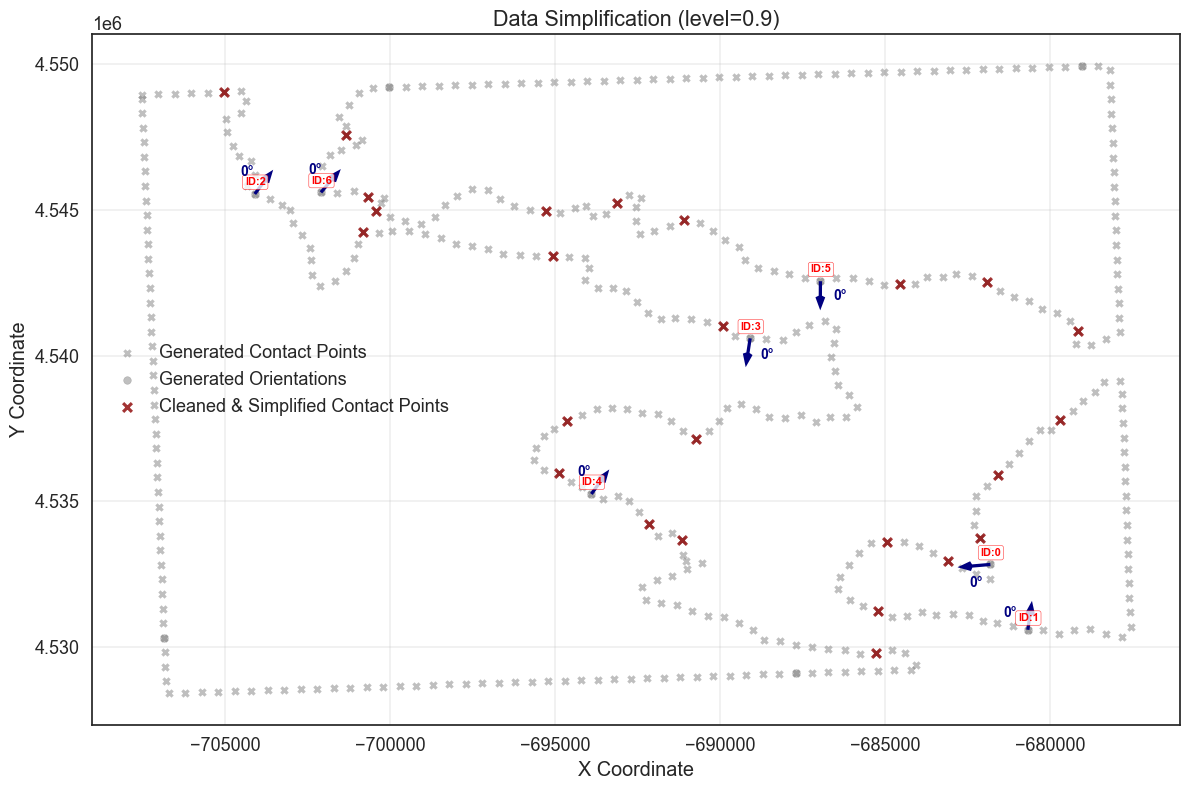

In [4]:
# Plot data
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
# Load the original generated points before cleaning/simplification
original_points = pd.read_csv(os.path.join(geomodel_dir, 'Simple-Models', 'contact_points.csv'))
original_orientations = HelperMethods.generate_orientations_from_points(original_points, default_dip=45, default_azimuth=90)
ax.scatter(original_points['X'], original_points['Y'], c='gray', s=20, alpha=0.5, marker='x', label='Generated Contact Points')
ax.scatter(original_orientations['X'], original_orientations['Y'], c='gray', s=30, alpha=0.5, label='Generated Orientations')
ax.scatter(points_df['X'], points_df['Y'], c='darkred', s=40, alpha=0.8, marker='x', label='Cleaned & Simplified Contact Points')

# Add arrows for orientation azimuth and dip annotations
import numpy as np
arrow_length = 1000  # adjust as needed for visibility
azimuth_rad = np.deg2rad(orientations_df['azimuth'])
dx = np.sin(azimuth_rad) * arrow_length
dy = np.cos(azimuth_rad) * arrow_length

# Plot arrows
ax.quiver(
    orientations_df['X'], orientations_df['Y'],
    dx, dy,
    angles='xy', scale_units='xy', scale=1, color='navy', width=0.003, headwidth=3, headlength=4
)

# Add point ID numbers next to each orientation point
for i, (_, row) in enumerate(orientations_df.iterrows()):
    ax.text(
        row['X'] - 300, row['Y'] + 300,  # Offset from point location
        f"ID:{i}",
        color='red', fontsize=8, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8, edgecolor='red')
    )

# Annotate dip values
for _, row in orientations_df.iterrows():
    # Position text perpendicular to arrow direction for better visibility
    azimuth_rad = np.deg2rad(row['azimuth'])
    perpendicular_offset = 600  # Distance perpendicular to arrow
    text_x = row['X'] + 0.5 * arrow_length * np.sin(azimuth_rad) - perpendicular_offset * np.cos(azimuth_rad)
    text_y = row['Y'] + 0.5 * arrow_length * np.cos(azimuth_rad) + perpendicular_offset * np.sin(azimuth_rad)

    ax.text(
        text_x, text_y,
        f"{row['dip']:.0f}°",
        color='navy', fontsize=10, ha='center', va='center', fontweight='bold'
    )

ax.set_title(f'Data Simplification (level={simplification_level})')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xlabel('X Coordinate'); ax.set_ylabel('Y Coordinate')
plt.tight_layout(); plt.show()

In [5]:
# Flip Orienatations if needed here

# Specify the IDs of orientations you want to flip by 180 degrees
ids_to_flip = []  # Add ID numbers here, e.g., [0, 3, 7, 12]

# Example usage (uncomment and modify as needed):
# ids_to_flip = [0, 3, 7]  # This would flip orientations with IDs 0, 3, and 7

# Apply the 180-degree flip to specified orientations
if ids_to_flip:
    for orientation_id in ids_to_flip:
        if orientation_id < len(orientations_df):
            original_azimuth = orientations_df.iloc[orientation_id]['azimuth']
            flipped_azimuth = (original_azimuth + 180) % 360
            orientations_df.iloc[orientation_id, orientations_df.columns.get_loc('azimuth')] = flipped_azimuth
            print(f"Flipped orientation ID {orientation_id}: {original_azimuth:.1f}° → {flipped_azimuth:.1f}°")
        else:
            print(f"Warning: ID {orientation_id} does not exist (max ID is {len(orientations_df)-1})")

    print(f"Total orientations flipped: {len([id for id in ids_to_flip if id < len(orientations_df)])}")
else:
    print("No orientations to flip (ids_to_flip list is empty)")

No orientations to flip (ids_to_flip list is empty)


In [6]:
# Save modified data + dynamic extent
tmp_dir = os.path.join(BASE_DIR, 'Simpel-Model-Inputs'); os.makedirs(tmp_dir, exist_ok=True)
mod_or_path = os.path.join(tmp_dir, 'orientations_mod.csv')
mod_pts_path = os.path.join(tmp_dir, 'points_mod.csv')
orientations_df.to_csv(mod_or_path, index=False)
points_df.to_csv(mod_pts_path, index=False)
_xmin = min(orientations_df.X.min(), points_df.X.min()); _xmax = max(orientations_df.X.max(), points_df.X.max())
_ymin = min(orientations_df.Y.min(), points_df.Y.min()); _ymax = max(orientations_df.Y.max(), points_df.Y.max())
_dx = _xmax - _xmin; _dy = _ymax - _ymin; _pad = 0.05
extent = [_xmin - _dx*_pad, _xmax + _dx*_pad, _ymin - _dy*_pad, _ymax + _dy*_pad, model_depth, max_z]

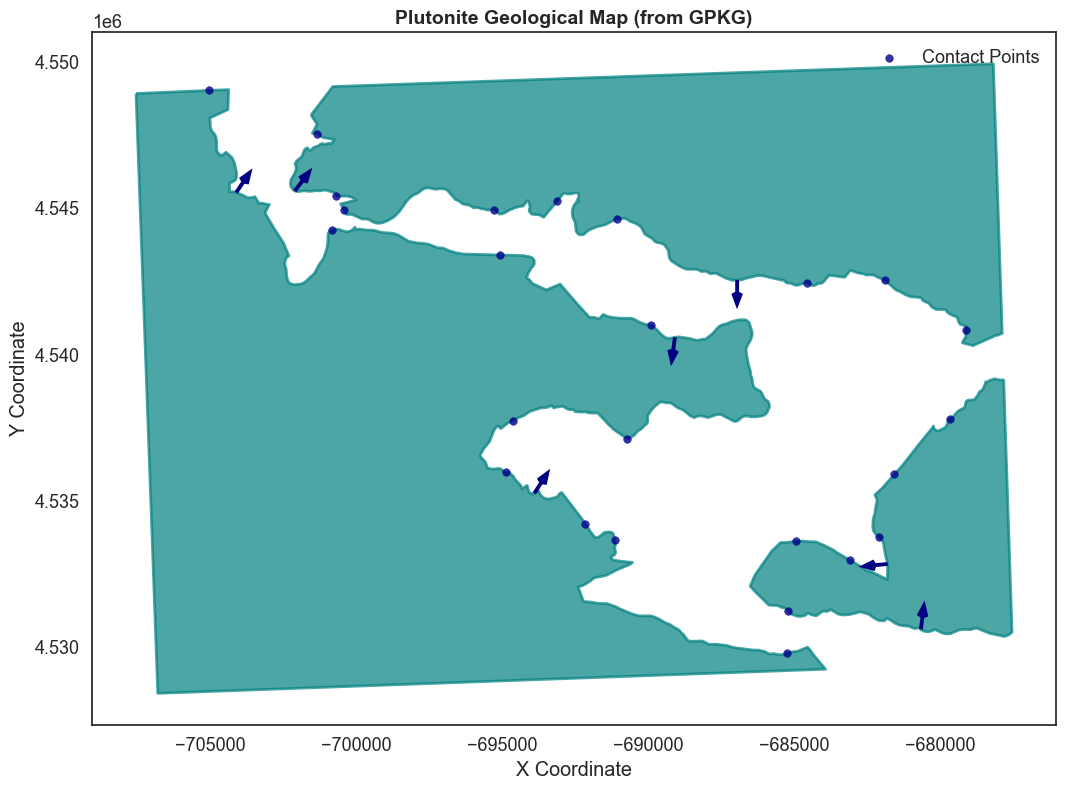

NameError: name 'geo_model' is not defined

In [7]:
# Display Plutonite Geological Map from GPKG
# Load the plutonite outline shapes
plutonite_gdf = gpd.read_file(gis_map_info)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot the plutonite shapes
plutonite_gdf.plot(ax=ax, facecolor='teal', edgecolor='teal', alpha=0.7, linewidth=2)

# Add the contact points on top
ax.scatter(points_df['X'], points_df['Y'], c='darkblue', s=30, alpha=0.8, marker='o', label='Contact Points', zorder=5)

# Add orientation arrows
arrow_length = 1000
azimuth_rad = np.deg2rad(orientations_df['azimuth'])
dx = np.sin(azimuth_rad) * arrow_length
dy = np.cos(azimuth_rad) * arrow_length

ax.quiver(
    orientations_df['X'], orientations_df['Y'],
    dx, dy,
    angles='xy', scale_units='xy', scale=1, color='navy', width=0.004, headwidth=3, headlength=4, zorder=6
)

ax.set_title('Plutonite Geological Map (from GPKG)', fontsize=14, fontweight='bold')
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.legend()

plt.tight_layout()
plt.show()


p = gpv.plot_2d(
    geo_model,
    section_names=['topography'],   # this triggers the top-down geological map
    show_topography=True,
    show_lith=True,
    show_boundaries=True,
    show_data=False
)
